## Setup

In [13]:
import os
import sys
import matplotlib.pyplot as plt
sys.path.append("..")
from simple_model.model import X, y

In [14]:
print(X.shape)
print(y.shape)

(150, 4)
(150,)


## Normal Version

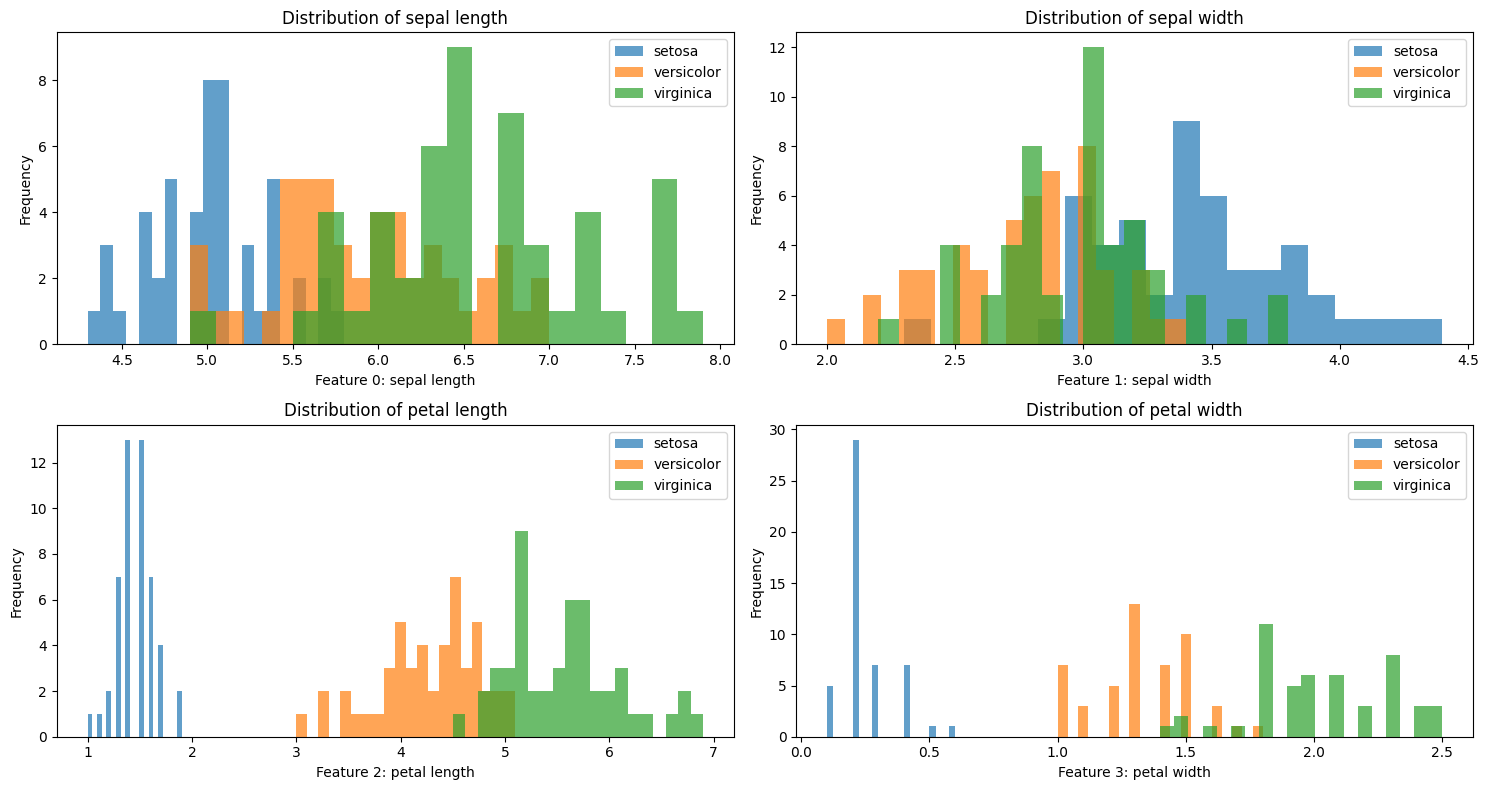

In [15]:
# plot feature distributions
import math
classes=["setosa", "versicolor", "virginica"]
feature_names = ["sepal length", "sepal width", "petal length", "petal width"]
cols=2
number_of_features=X.shape[1]
rows=math.ceil(number_of_features/cols)
plt.figure(figsize=(15, 4*rows))

cname=""
for i in range(number_of_features):
    plt.subplot(rows, cols, i+1)
    for j, class_name in enumerate(classes):
        plt.hist(X[y == j, i], bins=20, alpha=0.7, label=class_name)
        class_name = classes[j]
    plt.xlabel(f"Feature {i}: {feature_names[i]}")
    plt.ylabel("Frequency")
    plt.title(f"Distribution of {feature_names[i]}")
    plt.legend()
plt.tight_layout()
plt.show()

## Smoothed Version

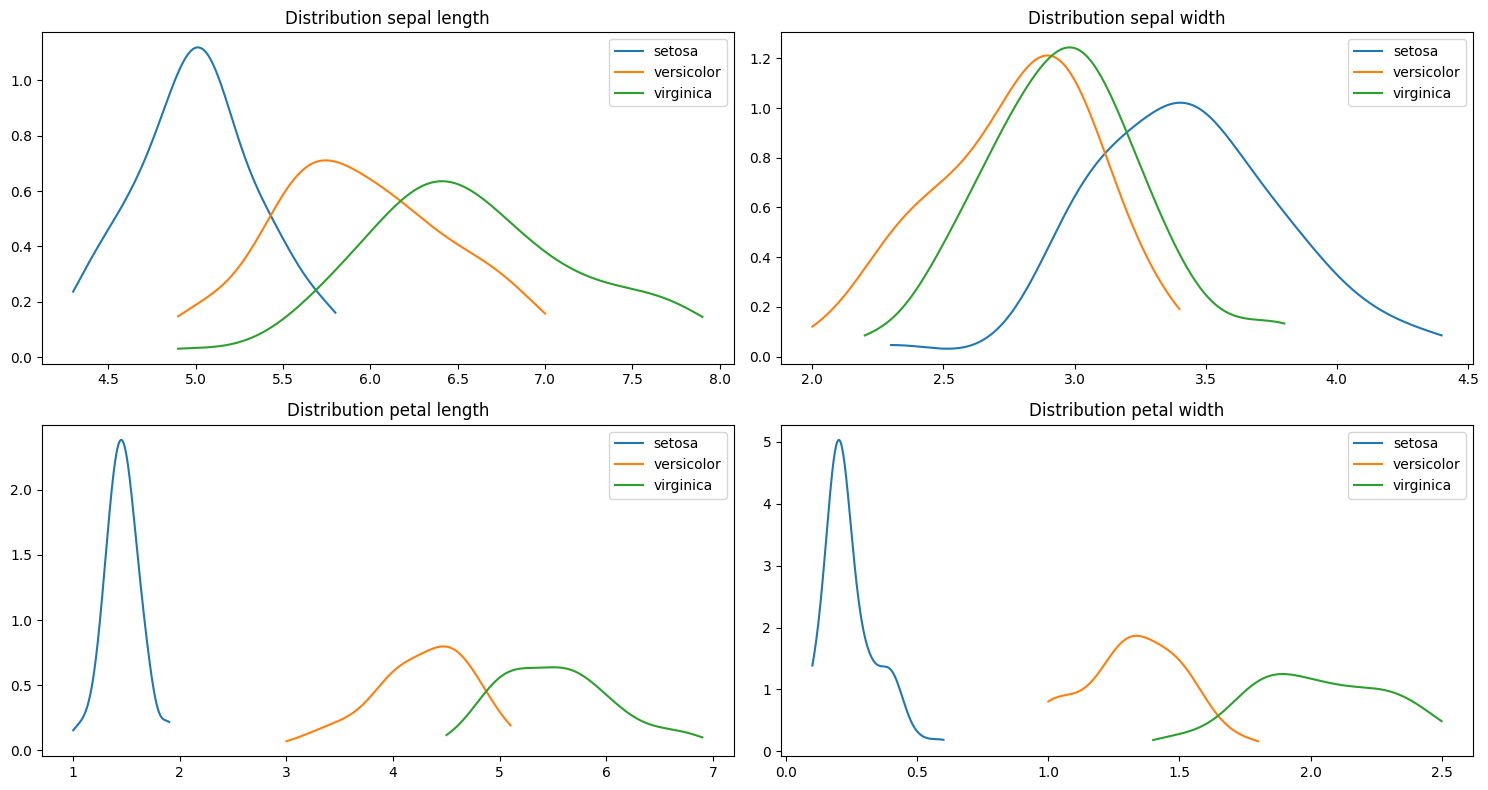

In [16]:
import numpy as np
from scipy.stats import gaussian_kde


plt.figure(figsize=(15, 4 * rows))

for i in range(number_of_features):
    plt.subplot(rows, cols, i + 1)
    
    for j, class_name in enumerate(classes):
        data = X[y == j, i]
        
        kde = gaussian_kde(data)
        x_vals = np.linspace(data.min(), data.max(), 200)
        y_vals = kde(x_vals)
        
        plt.plot(x_vals, y_vals, label=class_name)
    
    plt.title(f"Distribution {feature_names[i]}")
    plt.legend()

plt.tight_layout()
plt.show()

## Confusion Matrix

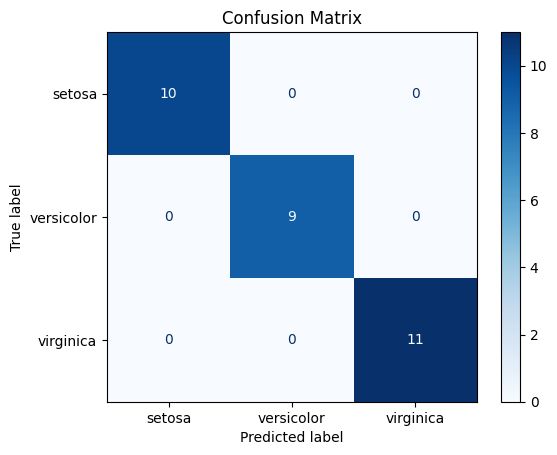

In [17]:
import pickle
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# load the model from the pickle file
with open(os.path.join("model_LR.pkl"), "rb") as f:
    model = pickle.load(f)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
y_pred = model.predict(X_test)
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix")
plt.show()